# Kwant — Theory and Practice · Solutions to the exercises of Part II (E2.1–E2.14)

*[Contents](00_Contents.ipynb) · exercises posed in [Chapter 12](12_3D_TI_Exercises_II_and_Beyond.ipynb) · the other solutions notebook: [`S1_Solutions_Part_I.ipynb`](S1_Solutions_Part_I.ipynb)*

Worked solutions for the exercises of Part II (posed at the end of Chapter 12). Each solution is self-contained given the preamble cell below, restates the task in one line, flags the exercise's origin, and ends in at least one `assert` that encodes the expected physics. Difficulty: ◦ direct, • some thought, ★ mini-project.

### In this notebook

- [E2.1 ◦ — Odd SSH chain](#E2.1-◦-—-Odd-SSH-chain)
- [E2.2 • — SSH domain wall](#E2.2-•-—-SSH-domain-wall)
- [E2.3 ★ — Kitaev chain with winding number 2](#E2.3-★-—-Kitaev-chain-with-winding-number-2)
- [E2.4 ◦ — ZBP height vs wire length](#E2.4-◦-—-ZBP-height-vs-wire-length)
- [E2.5 ◦ — Pump cycles: reversed and non-winding](#E2.5-◦-—-Pump-cycles:-reversed-and-non-winding)
- [E2.6 ◦ — Haldane boundary scales with $t_2$](#E2.6-◦-—-Haldane-boundary-scales-with-$t_2$)
- [E2.7 • — Haldane armchair ribbon](#E2.7-•-—-Haldane-armchair-ribbon)
- [E2.8 • — Killing the QSH edge with a staggered mass](#E2.8-•-—-Killing-the-QSH-edge-with-a-staggered-mass)
- [E2.9 ★ — Majorana in a p+ip vortex core](#E2.9-★-—-Majorana-in-a-p+ip-vortex-core)
- [E2.10 ◦ — Breaking the BBH mirror protection](#E2.10-◦-—-Breaking-the-BBH-mirror-protection)
- [E2.11 • — Weyl node migration and annihilation](#E2.11-•-—-Weyl-node-migration-and-annihilation)
- [E2.12 ★ — Weak topological indices](#E2.12-★-—-Weak-topological-indices)
- [E2.13 • — Surface-state hybridisation in thin TI films](#E2.13-•-—-Surface-state-hybridisation-in-thin-TI-films)
- [E2.14 ◦ (pencil) — Particle-hole symmetry pins E = 0](#E2.14-◦-(pencil)-—-Particle-hole-symmetry-pins-E-=-0)

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- preamble: shared imports and helpers used across the solutions ----------
import numpy as np
import kwant, kwant.wraparound
import scipy.linalg
import scipy.sparse.linalg as sla
from math import gcd
from matplotlib import pyplot

s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

def make_wire(W=10, L=30, t=1.0, norbs=1, onsite=None, hop=None):
    """The standard two-terminal square-lattice wire of the main notebook."""
    lat = kwant.lattice.square(norbs=norbs)
    if onsite is None:
        onsite = 4 * t if norbs == 1 else 4 * t * s0
    if hop is None:
        hop = -t if norbs == 1 else -t * s0
    syst = kwant.Builder()
    syst[(lat(x, y) for x in range(L) for y in range(W))] = onsite
    syst[lat.neighbors()] = hop
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    lead[(lat(0, j) for j in range(W))] = onsite
    lead[lat.neighbors()] = hop
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst, lat

def chern_fhs(hfunc, n_occ, n1=24, n2=24):
    """FHS Chern number (same construction as the main notebook)."""
    xs1 = np.linspace(0, 2 * np.pi, n1, endpoint=False)
    xs2 = np.linspace(0, 2 * np.pi, n2, endpoint=False)
    fr = np.empty((n1, n2), dtype=object)
    for i, x1 in enumerate(xs1):
        for j, x2 in enumerate(xs2):
            fr[i, j] = np.linalg.eigh(hfunc(x1, x2))[1][:, :n_occ]
    link = lambda a, b: np.linalg.det(a.conj().T @ b)
    F = 0.0
    for i in range(n1):
        for j in range(n2):
            F += np.angle(link(fr[i, j], fr[(i+1) % n1, j]) *
                          link(fr[(i+1) % n1, j], fr[(i+1) % n1, (j+1) % n2]) *
                          link(fr[(i+1) % n1, (j+1) % n2], fr[i, (j+1) % n2]) *
                          link(fr[i, (j+1) % n2], fr[i, j]))
    return int(round(F / (2 * np.pi)))

def bloch_native(bulk_builder):
    """Bloch Hamiltonian in wraparound's native (2pi-periodic) momenta."""
    w = kwant.wraparound.wraparound(bulk_builder).finalized()
    return lambda t1, t2: w.hamiltonian_submatrix(params=dict(k_x=t1, k_y=t2))

print("preamble ready")

preamble ready


## E2.1 ◦ — Odd SSH chain
*(after Asbóth, Oroszlány & Pályi, ch. 1)* — Odd chain: sublattice imbalance
forces one exact zero mode for any $t_1, t_2$; it lives on the majority
sublattice, on the weak-bond end.

t1=1.0, t2=0.5:  E0 = +6.30e-16,  A-sublattice weight = 1.0000,  left-end weight = 0.00
t1=0.5, t2=1.0:  E0 = +4.44e-16,  A-sublattice weight = 1.0000,  left-end weight = 0.98


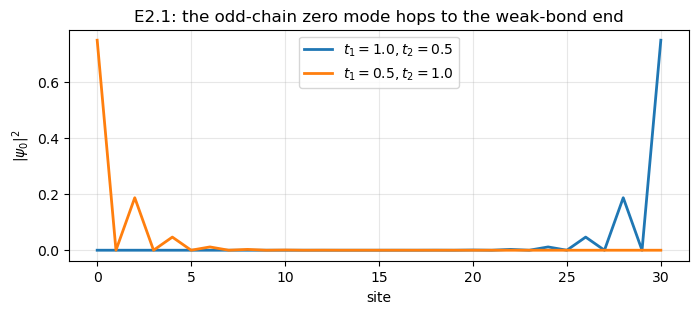

chiral symmetry pins it at E=0 for ANY hoppings; only its side moves


In [2]:
def ssh_odd(t1, t2, ncells=15):
    N = 2 * ncells + 1                     # odd: ends on an A site
    H = np.zeros((N, N))
    for i in range(N - 1):
        H[i, i + 1] = H[i + 1, i] = t1 if i % 2 == 0 else t2
    return H

for t1, t2 in [(1.0, 0.5), (0.5, 1.0)]:
    ev, vec = np.linalg.eigh(ssh_odd(t1, t2))
    i0 = np.argmin(np.abs(ev))
    wA = np.abs(vec[0::2, i0]) ** 2
    print(f"t1={t1}, t2={t2}:  E0 = {ev[i0]:+.2e},  "
          f"A-sublattice weight = {(wA.sum()):.4f},  "
          f"left-end weight = {np.abs(vec[:6, i0]) ** 2 @ np.ones(6):.2f}")
    assert abs(ev[i0]) < 1e-12
    assert wA.sum() > 0.999                # zero mode lives on A only
pyplot.figure(figsize=(8, 3))
for t1, t2, col in [(1.0, 0.5, 'C0'), (0.5, 1.0, 'C1')]:
    ev, vec = np.linalg.eigh(ssh_odd(t1, t2))
    i0 = np.argmin(np.abs(ev))
    pyplot.plot(np.abs(vec[:, i0]) ** 2, col, lw=2,
                label=f"$t_1={t1}, t_2={t2}$")
pyplot.legend(); pyplot.grid(alpha=.3)
pyplot.xlabel("site"); pyplot.ylabel(r"$|\psi_0|^2$")
pyplot.title("E2.1: the odd-chain zero mode hops to the weak-bond end")
pyplot.show()
print("chiral symmetry pins it at E=0 for ANY hoppings; only its side moves")

## E2.2 • — SSH domain wall
*(after Jackiw & Rebbi, PRD 13, 3398 (1976); Asbóth ch. 1)* — A wall
between the two dimerisations binds a sublattice-polarised zero mode: the
lattice Jackiw-Rebbi soliton with charge $e/2$.

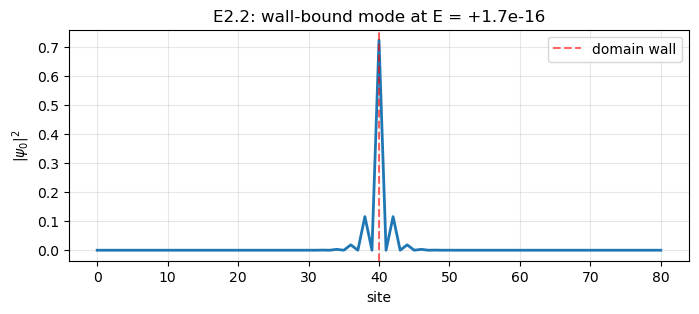

sublattice polarisation: A weight = 1.000 (fully polarised, the Jackiw-Rebbi half-charge carrier)


In [3]:
N = 81
H = np.zeros((N, N))
for i in range(N - 1):
    strong = (i % 2 == 0) if i < N // 2 else (i % 2 == 1)
    H[i, i + 1] = H[i + 1, i] = 1.0 if strong else 0.4
ev, vec = np.linalg.eigh(H)
i0 = np.argmin(np.abs(ev))
dens = np.abs(vec[:, i0]) ** 2
pyplot.figure(figsize=(8, 3))
pyplot.plot(dens, lw=2)
pyplot.axvline(N // 2, color='r', ls='--', alpha=.6, label="domain wall")
pyplot.xlabel("site"); pyplot.ylabel(r"$|\psi_0|^2$")
pyplot.title(f"E2.2: wall-bound mode at E = {ev[i0]:+.1e}")
pyplot.legend(); pyplot.grid(alpha=.3); pyplot.show()
assert abs(ev[i0]) < 1e-10
assert dens[N//2 - 8: N//2 + 8].sum() > 0.8
wA = np.abs(vec[0::2, i0]) ** 2
print(f"sublattice polarisation: A weight = {wA.sum():.3f} "
      "(fully polarised, the Jackiw-Rebbi half-charge carrier)")

## E2.3 ★ — Kitaev chain with winding number 2
*(inspired by topocondmat.org, week 1)* — Adding NNN hopping and pairing
gives class-BDI winding $W=2$: two Majoranas per end.  They survive
$\tau_z$-type (chemical-potential) disorder but split under a $\tau_x$
perturbation, which breaks the chiral symmetry.

In [4]:
t2k, D2k = 1.0, 1.0          # dominant NNN terms
t1k, D1k, muk = 0.3, 0.3, 0.0

def kitaev2(tx_pert=0.0, w_dis=0.0, L=60, seed=1):
    rng = np.random.default_rng(seed)
    H = np.zeros((2 * L, 2 * L), dtype=complex)
    for x in range(L):
        on = -muk * sz + tx_pert * sx + w_dis * (rng.random() - .5) * sz
        H[2*x:2*x+2, 2*x:2*x+2] = on
        for d, tt, DD in [(1, t1k, D1k), (2, t2k, D2k)]:
            if x + d < L:
                hop = -tt * sz - 1j * DD * sy
                H[2*x:2*x+2, 2*(x+d):2*(x+d)+2] = hop
                H[2*(x+d):2*(x+d)+2, 2*x:2*x+2] = hop.conj().T
    return H

def winding():
    ks = np.linspace(0, 2 * np.pi, 401)
    h = -muk - 2 * t1k * np.cos(ks) - 2 * t2k * np.cos(2 * ks)
    d = 2 * D1k * np.sin(ks) + 2 * D2k * np.sin(2 * ks)
    ang = np.unwrap(np.angle(h + 1j * d))
    return int(round((ang[-1] - ang[0]) / (2 * np.pi)))

W = winding()
ev = np.linalg.eigvalsh(kitaev2())
nz = int(np.sum(np.abs(ev) < 1e-3))
print(f"winding number W = {W};  near-zero modes in a finite chain: {nz} "
      "(= 2 Majoranas per end)")
assert abs(W) == 2 and nz == 4

ev_dis = np.linalg.eigvalsh(kitaev2(w_dis=0.4))
ev_tx = np.linalg.eigvalsh(kitaev2(tx_pert=0.05))
print(f"with tau_z disorder W=0.4 : {np.sum(np.abs(ev_dis) < 1e-3)} zero modes"
      " (chiral symmetry intact)")
print(f"with tau_x perturbation   : {np.sum(np.abs(ev_tx) < 1e-3)} zero modes"
      " (chiral symmetry broken -> Majoranas pairwise split)")
assert np.sum(np.abs(ev_dis) < 1e-3) == 4
assert np.sum(np.abs(ev_tx) < 1e-3) < 4

winding number W = -2;  near-zero modes in a finite chain: 4 (= 2 Majoranas per end)
with tau_z disorder W=0.4 : 4 zero modes (chiral symmetry intact)
with tau_x perturbation   : 0 zero modes (chiral symmetry broken -> Majoranas pairwise split)


## E2.4 ◦ — ZBP height vs wire length
*(after topocondmat.org, week 2)* — The Majorana splitting decays
exponentially with $L$, and with it the deviation of the zero-bias peak
from $2e^2/h$.

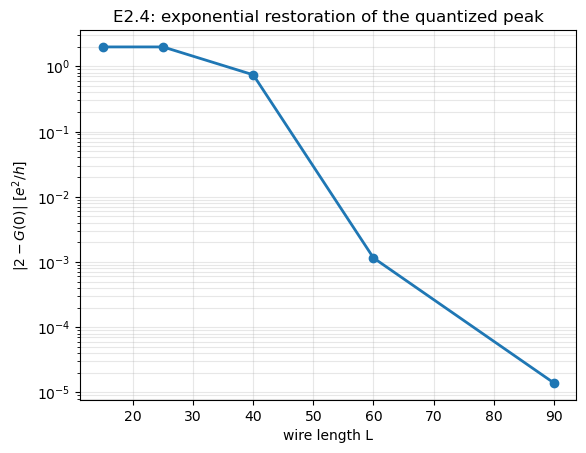

deviation tracks the Majorana overlap ~ exp(-L/xi)


In [5]:
k4 = np.kron
t, alpha, Delta, mu = 1.0, 0.4, 0.25, 0.2
Bc = np.hypot(Delta, mu)
lat = kwant.lattice.chain(norbs=4)
onsite_nw = (2*t - mu) * k4(sz, s0) + 1.8 * Bc * k4(np.eye(2), sx) \
    + Delta * k4(sx, s0)
hop_nw = -t * k4(sz, s0) + 0.5j * alpha * k4(sz, sy)

def ns_wire_L(L):
    syst = kwant.Builder()
    syst[(lat(x) for x in range(L))] = onsite_nw
    syst[kwant.builder.HoppingKind((1,), lat, lat)] = hop_nw
    syst[lat(0)] = onsite_nw + 1.2 * k4(sz, s0)
    lead = kwant.Builder(kwant.TranslationalSymmetry((-1,)),
                         conservation_law=-k4(sz, s0))
    lead[lat(0)] = (2*t - 1.5) * k4(sz, s0) + 1.8 * Bc * k4(np.eye(2), sx)
    lead[kwant.builder.HoppingKind((1,), lat, lat)] = -t * k4(sz, s0)
    syst.attach_lead(lead)
    return syst.finalized()

def zbp(L):
    sm = kwant.smatrix(ns_wire_L(L), 1e-4)
    N = sm.submatrix((0, 0), (0, 0)).shape[0]
    return N - sm.transmission((0, 0), (0, 0)) + sm.transmission((0, 1), (0, 0))

Ls = [15, 25, 40, 60, 90]
dev = [abs(2 - zbp(L)) for L in Ls]
pyplot.semilogy(Ls, np.maximum(dev, 1e-12), 'o-', lw=2)
pyplot.xlabel("wire length L"); pyplot.ylabel(r"$|2 - G(0)|\ [e^2/h]$")
pyplot.title("E2.4: exponential restoration of the quantized peak")
pyplot.grid(alpha=.3, which='both'); pyplot.show()
assert dev[-1] < dev[0]
print("deviation tracks the Majorana overlap ~ exp(-L/xi)")

## E2.5 ◦ — Pump cycles: reversed and non-winding
*(original)* — Reversing the cycle flips the pumped charge; a cycle that
misses the gapless point pumps nothing.

In [6]:
t0p, d0p, D0p = 1.0, 0.6, 0.6

def h_rm(k, phi, direction=+1, center=0.0):
    de = center + d0p * np.cos(direction * phi)
    D = D0p * np.sin(direction * phi)
    q = (t0p + de) + (t0p - de) * np.exp(1j * k)
    return np.array([[D, q], [np.conj(q), -D]])

C_fwd = chern_fhs(lambda k, p: h_rm(k, p, +1), 1, 36, 36)
C_bwd = chern_fhs(lambda k, p: h_rm(k, p, -1), 1, 36, 36)
C_off = chern_fhs(lambda k, p: h_rm(k, p, +1, center=1.5), 1, 36, 36)
print(f"forward cycle: C = {C_fwd:+d};  reversed: C = {C_bwd:+d};  "
      f"shifted (not encircling): C = {C_off:+d}")
assert C_bwd == -C_fwd and abs(C_fwd) == 1 and C_off == 0

forward cycle: C = -1;  reversed: C = +1;  shifted (not encircling): C = +0


## E2.6 ◦ — Haldane boundary scales with $t_2$
*(original)* — At $t_2 = 0.05$ the lobe boundary sits at
$3\sqrt{3}\,t_2\sin\phi$, five times smaller than in the main text.

In [7]:
lat_h = kwant.lattice.honeycomb(norbs=1)
ha, hb = lat_h.sublattices
nnn_a = [kwant.builder.HoppingKind(v, ha, ha) for v in [(1, 0), (-1, 1), (0, -1)]]
nnn_b = [kwant.builder.HoppingKind(v, hb, hb) for v in [(1, 0), (-1, 1), (0, -1)]]

def haldane(M, phi, t2=0.05):
    s = kwant.Builder(kwant.TranslationalSymmetry(*lat_h.prim_vecs))
    s[ha(0, 0)] = M; s[hb(0, 0)] = -M
    s[lat_h.neighbors()] = 1.0
    for k in nnn_a:
        s[k] = t2 * np.exp(1j * phi)
    for k in nnn_b:
        s[k] = t2 * np.exp(-1j * phi)
    return s

t2 = 0.05
Mc = 3 * np.sqrt(3) * t2
for M, expected in [(0.8 * Mc, 1), (1.2 * Mc, 0)]:
    C = chern_fhs(bloch_native(haldane(M, np.pi / 2, t2)), 1, 30, 30)
    print(f"t2={t2}, M={M:.3f} ({M/Mc:.1f} Mc):  C = {C}")
    assert abs(C) == (1 if expected else 0)
print(f"boundary confirmed at 3*sqrt(3)*t2 = {Mc:.3f}, rescaled with t2")

t2=0.05, M=0.208 (0.8 Mc):  C = 1


t2=0.05, M=0.312 (1.2 Mc):  C = 0
boundary confirmed at 3*sqrt(3)*t2 = 0.260, rescaled with t2


## E2.7 • — Haldane armchair ribbon
*(after topocondmat.org, week 4)* — Chiral edge modes cross the gap for the
armchair termination too: the invariant is a bulk property.

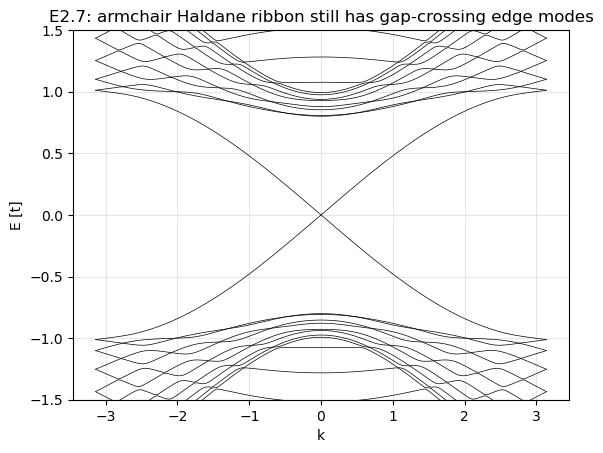

min |E| across BZ: 0.0000  (edge modes cross zero)


In [8]:
def haldane_armchair(W=10, t2=0.15, phi=np.pi / 2):
    sym = kwant.TranslationalSymmetry(lat_h.vec((-1, 2)))   # armchair direction
    s = kwant.Builder(sym)
    s[lat_h.shape(lambda p: 0 <= p[0] < W, (0.5, 0.1))] = 0.0
    s[lat_h.neighbors()] = 1.0
    for k in nnn_a:
        s[k] = t2 * np.exp(1j * phi)
    for k in nnn_b:
        s[k] = t2 * np.exp(-1j * phi)
    return s.finalized()

frib = haldane_armchair()
bands = kwant.physics.Bands(frib)
ks = np.linspace(-np.pi, np.pi, 161)
allE = np.array([bands(k) for k in ks])
pyplot.plot(ks, allE, 'k-', lw=.5)
pyplot.ylim(-1.5, 1.5)
pyplot.xlabel("k"); pyplot.ylabel("E [t]")
pyplot.title("E2.7: armchair Haldane ribbon still has gap-crossing edge modes")
pyplot.grid(alpha=.3); pyplot.show()
min_gap = min(np.abs(bands(k)).min() for k in ks)
print(f"min |E| across BZ: {min_gap:.4f}  (edge modes cross zero)")
assert min_gap < 0.05

## E2.8 • — Killing the QSH edge with a staggered mass
*(after Kane & Mele, PRL 95, 226801 (2005))* — Edge conductance collapses
when $M$ crosses $3\sqrt{3}\lambda_{SO} \approx 0.52$.

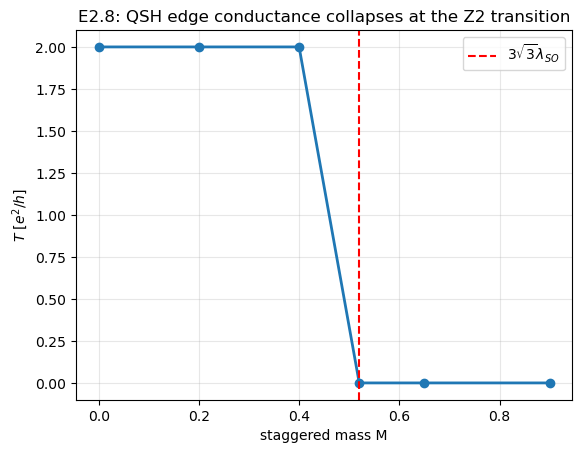

In [9]:
lam_so = 0.1
lat_km = kwant.lattice.honeycomb(norbs=2)
ka, kb = lat_km.sublattices
km_nnn_a = [kwant.builder.HoppingKind(v, ka, ka) for v in [(1, 0), (-1, 1), (0, -1)]]
km_nnn_b = [kwant.builder.HoppingKind(v, kb, kb) for v in [(1, 0), (-1, 1), (0, -1)]]

def km_bar_M(M, W=8, L=12):
    def fill(s, shape, origin):
        s[lat_km.shape(shape, origin)] = \
            (lambda site: (M if site.family == ka else -M) * s0)
        s[lat_km.neighbors()] = 1.0 * s0
        for k in km_nnn_a:
            s[k] = 1j * lam_so * sz
        for k in km_nnn_b:
            s[k] = -1j * lam_so * sz
    syst = kwant.Builder()
    fill(syst, lambda p: 0 <= p[0] < L and 0 <= p[1] < W * np.sqrt(3) / 2,
         (1, 1))
    syst.eradicate_dangling()
    lead = kwant.Builder(kwant.TranslationalSymmetry(lat_km.vec((1, 0))))
    fill(lead, lambda p: 0 <= p[1] < W * np.sqrt(3) / 2, (0, 1))
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

Ms = [0.0, 0.2, 0.4, 0.52, 0.65, 0.9]
T = [kwant.smatrix(km_bar_M(M), 0.05).transmission(1, 0) for M in Ms]
pyplot.plot(Ms, T, 'o-', lw=2)
pyplot.axvline(3 * np.sqrt(3) * lam_so, color='r', ls='--',
               label=r"$3\sqrt{3}\lambda_{SO}$")
pyplot.xlabel("staggered mass M"); pyplot.ylabel(r"$T\ [e^2/h]$")
pyplot.title("E2.8: QSH edge conductance collapses at the Z2 transition")
pyplot.legend(); pyplot.grid(alpha=.3); pyplot.show()
assert T[0] > 1.9 and T[-1] < 0.3

## E2.9 ★ — Majorana in a p+ip vortex core
*(after Read & Green, PRB 61, 10267 (2000))* — A unit vortex in
$\Delta(\mathbf r)$ binds a near-zero mode in the core; its partner lives
on the edge, and their splitting stays deep below the gap, oscillating as $\cos(k_F R)e^{-R/\xi}$ with radius.

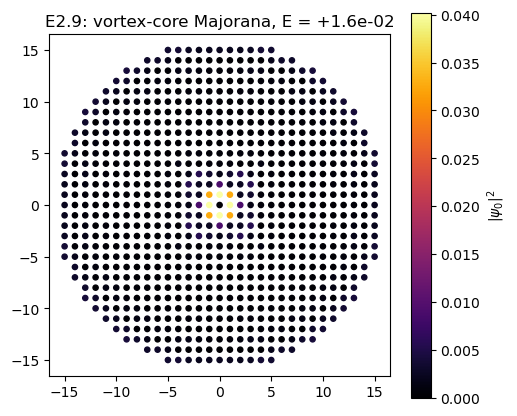

lowest-|E| splitting vs radius: {8: '1.42e-02', 12: '1.79e-02', 16: '1.55e-02'}
core+edge weight of the two lowest states: 0.80
a Majorana in the vortex core, its partner delocalised on the edge; their overlap oscillates with k_F R under the exponential envelope


In [10]:
t, Delta, mu = 1.0, 0.5, -2.0

def pip_vortex(R):
    pts = [(x, y) for x in range(-R, R + 1) for y in range(-R, R + 1)
           if x * x + y * y < R * R]
    index = {p: i for i, p in enumerate(pts)}
    N = len(pts)
    H = np.zeros((2 * N, 2 * N), dtype=complex)
    for (x, y), i in index.items():
        H[2*i, 2*i] = -mu
        H[2*i+1, 2*i+1] = +mu
        for dx, dy in [(1, 0), (0, 1)]:
            if (x + dx, y + dy) in index:
                j = index[(x + dx, y + dy)]
                mx, my = x + dx / 2, y + dy / 2
                vort = np.exp(1j * np.arctan2(my, mx))
                pair = 0.5 * Delta * (dx + 1j * dy) * vort
                H[2*i, 2*j] += -t;      H[2*i+1, 2*j+1] += +t
                H[2*i, 2*j+1] += pair;  H[2*i+1, 2*j] += -np.conj(pair)
                blk = H[2*i:2*i+2, 2*j:2*j+2]
                H[2*j:2*j+2, 2*i:2*i+2] = blk.conj().T
    return np.array(pts, float), H

splits = []
for R in (8, 12, 16):
    pts, H = pip_vortex(R)
    assert np.allclose(H, H.conj().T)
    ev, vec = np.linalg.eigh(H)
    order = np.argsort(np.abs(ev))[:2]
    splits.append(np.abs(ev[order]).max())
    if R == 16:
        dens = (np.abs(vec[:, order[0]]) ** 2).reshape(-1, 2).sum(axis=1)
        pyplot.figure(figsize=(5.5, 5))
        pyplot.scatter(pts[:, 0], pts[:, 1], c=dens, s=14, cmap='inferno')
        pyplot.colorbar(label=r"$|\psi_0|^2$")
        pyplot.gca().set_aspect('equal')
        pyplot.title(f"E2.9: vortex-core Majorana, E = {ev[order[0]]:+.1e}")
        pyplot.show()
print("lowest-|E| splitting vs radius:",
      {R: f"{s:.2e}" for R, s in zip((8, 12, 16), splits)})
# NB: the splitting is NOT monotonic in R -- it oscillates as
# cos(k_F R) exp(-R/xi) [Cheng et al., PRL 103, 107001 (2009)] -- but it
# stays far below the bulk gap, and the states live on core + edge:
assert max(splits) < 0.1 * Delta
r = np.linalg.norm(pts, axis=1)
pair_dens = (np.abs(vec[:, order]) ** 2).sum(axis=1).reshape(-1, 2).sum(axis=1)
core_edge = pair_dens[(r < 3.5) | (r > 16 - 3)].sum() / pair_dens.sum()
print(f"core+edge weight of the two lowest states: {core_edge:.2f}")
assert core_edge > 0.6
print("a Majorana in the vortex core, its partner delocalised on the edge; "
      "their overlap oscillates with k_F R under the exponential envelope")

## E2.10 ◦ — Breaking the BBH mirror protection
*(after Benalcazar, Bernevig & Hughes, Science 357, 61 (2017))* — A
sublattice-staggered onsite term breaks the protecting mirrors: the corner
quartet splits linearly.

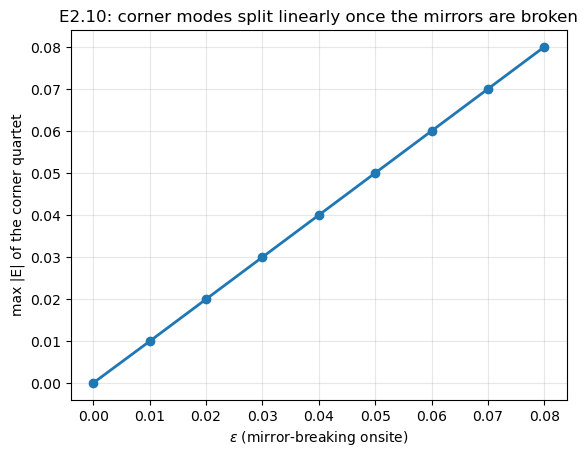

splitting slope d|E|/d eps = 1.00  (linear, protection lost)


In [11]:
gam, lam = 0.3, 1.0
on0 = np.array([[0, 0, gam, gam], [0, 0, -gam, gam],
                [gam, -gam, 0, 0], [gam, gam, 0, 0]], float)
hx = np.zeros((4, 4)); hx[0, 2] = lam; hx[3, 1] = lam
hy = np.zeros((4, 4)); hy[0, 3] = lam; hy[2, 1] = -lam
latq = kwant.lattice.square(norbs=4)

def bbh(eps, Nc=8):
    s = kwant.Builder()
    pert = np.diag([eps, eps, -eps, -eps])
    s[(latq(x, y) for x in range(Nc) for y in range(Nc))] = on0 + pert
    s[kwant.builder.HoppingKind((1, 0), latq, latq)] = hx
    s[kwant.builder.HoppingKind((0, 1), latq, latq)] = hy
    return s.finalized()

epss = np.linspace(0, 0.08, 9)
emax = []
for eps in epss:
    ev = np.linalg.eigvalsh(bbh(eps).hamiltonian_submatrix())
    quart = np.sort(np.abs(ev))[:4]
    emax.append(quart.max())
pyplot.plot(epss, emax, 'o-', lw=2)
pyplot.xlabel(r"$\epsilon$ (mirror-breaking onsite)")
pyplot.ylabel("max |E| of the corner quartet")
pyplot.title("E2.10: corner modes split linearly once the mirrors are broken")
pyplot.grid(alpha=.3); pyplot.show()
slope = np.polyfit(epss[1:], emax[1:], 1)[0]
print(f"splitting slope d|E|/d eps = {slope:.2f}  (linear, protection lost)")
assert emax[0] < 1e-3 and emax[-1] > 0.02   # eps=0 residual = finite-size (gam/lam)^Nc

## E2.11 • — Weyl node migration and annihilation
*(original)* — Nodes sit at $\cos k_0 = m_0/t - 2$: they merge at
$k_z = \pi$ when $m_0 = t$ and at $k_z = 0$ when $m_0 = 3t$; beyond, the
slices are trivial.  Below $m_0 = t$ new node pairs appear on other axes.

In [12]:
def h_weyl(kx, ky, kz, m0):
    M = m0 - (np.cos(kx) + np.cos(ky) + np.cos(kz))
    return np.sin(kx) * sx + np.sin(ky) * sy + M * sz

def slice_chern(kz, m0, n=20):
    return chern_fhs(lambda kx, ky: h_weyl(kx, ky, kz, m0), 1, n, n)

for m0 in (2.5, 2.95, 3.2):
    if m0 < 3:
        k0 = np.arccos(m0 - 2)
        print(f"m0={m0}: nodes at kz = ±{k0:.3f};  "
              f"C(kz=0) = {slice_chern(0.0, m0)}")
    else:
        print(f"m0={m0}: no node solution;  C(kz=0) = {slice_chern(0.0, m0)}")
assert slice_chern(0.0, 2.5) != 0 and slice_chern(0.0, 3.2) == 0

# below m0 = 1 the nodes reappear on the (pi, 0, kz) axis
m0 = 0.5
kz_new = np.arccos(m0)      # M(pi,0,kz) = m0 - cos kz = 0
gap = np.abs(np.linalg.eigvalsh(h_weyl(np.pi, 0, kz_new, m0))).min()
print(f"m0={m0}: gap at (pi, 0, {kz_new:.3f}) = {gap:.2e}  "
      "(a fresh Weyl pair born on another axis)")
assert gap < 1e-12

m0=2.5: nodes at kz = ±1.047;  C(kz=0) = 1
m0=2.95: nodes at kz = ±0.318;  C(kz=0) = 1


m0=3.2: no node solution;  C(kz=0) = 0


m0=0.5: gap at (pi, 0, 1.047) = 1.65e-16  (a fresh Weyl pair born on another axis)


## E2.12 ★ — Weak topological indices
*(after Fu & Kane, PRB 76, 045302 (2007))* — At $m_0 = 0.5$ the band
inversions occur at $\Gamma$ *and* the three X points: $\nu_0 = 0$ but
$(\nu_1\nu_2\nu_3) = (111)$ — a weak TI, a stack of 2D QSH layers.

In [13]:
from itertools import product
lam3 = 1.0
G0 = np.kron(sz, s0)
Gx, Gy, Gz = np.kron(sx, sx), np.kron(sx, sy), np.kron(sx, sz)

def h_ti(kx, ky, kz, m0):
    m = m0 - (np.cos(kx) + np.cos(ky) + np.cos(kz))
    return m * G0 + lam3 * (np.sin(kx) * Gx + np.sin(ky) * Gy
                            + np.sin(kz) * Gz)

def parity(trim, m0):
    occ = np.linalg.eigh(h_ti(*trim, m0))[1][:, :2]
    return np.sign(np.real(np.linalg.eigvalsh(occ.conj().T @ G0 @ occ)[0]))

def z2_indices(m0):
    trims = list(product((0.0, np.pi), repeat=3))
    xi = {t_: parity(t_, m0) for t_ in trims}
    nu0 = 0 if np.prod(list(xi.values())) > 0 else 1
    nus = []
    for axis in range(3):
        sel = [t_ for t_ in trims if t_[axis] == np.pi]
        nus.append(0 if np.prod([xi[t_] for t_ in sel]) > 0 else 1)
    return nu0, tuple(nus), xi

for m0 in (2.0, 0.5):
    nu0, nus, xi = z2_indices(m0)
    inverted = [t_ for t_, p in xi.items() if p < 0]
    print(f"m0={m0}:  (nu0; nu1 nu2 nu3) = ({nu0}; {nus[0]}{nus[1]}{nus[2]})"
          f"   [{len(inverted)} inverted TRIM]")
assert z2_indices(2.0)[0] == 1
assert z2_indices(0.5)[0] == 0 and z2_indices(0.5)[1] == (1, 1, 1)

# slab check: the weak phase has an EVEN number of surface Dirac cones on (001)
Nz = 16
hopz = -0.5 * G0 + lam3 * Gz / 2j
def slab_gap(kx, ky, m0):
    on = (m0 - np.cos(kx) - np.cos(ky)) * G0 + \
        lam3 * (np.sin(kx) * Gx + np.sin(ky) * Gy)
    H = np.zeros((4 * Nz, 4 * Nz), complex)
    for z in range(Nz):
        H[4*z:4*z+4, 4*z:4*z+4] = on
        if z + 1 < Nz:
            H[4*z:4*z+4, 4*z+4:4*z+8] = hopz
            H[4*z+4:4*z+8, 4*z:4*z+4] = hopz.conj().T
    return np.abs(np.linalg.eigvalsh(H)).min()

cones = [k for k in [(0, 0), (np.pi, 0), (0, np.pi), (np.pi, np.pi)]
         if slab_gap(*k, 0.5) < 0.05]
print(f"weak TI (001) slab: gapless surface points at {cones} "
      f"-> {len(cones)} Dirac cones (even, hence 'weak')")
assert len(cones) % 2 == 0 and len(cones) > 0

m0=2.0:  (nu0; nu1 nu2 nu3) = (1; 000)   [7 inverted TRIM]
m0=0.5:  (nu0; nu1 nu2 nu3) = (0; 111)   [4 inverted TRIM]
weak TI (001) slab: gapless surface points at [(3.141592653589793, 0), (0, 3.141592653589793)] -> 2 Dirac cones (even, hence 'weak')


## E2.13 • — Surface-state hybridisation in thin TI films
*(original; cf. Zhang et al., Nat. Phys. 6, 584 (2010) for Bi₂Se₃)* — The
two surfaces of a thin slab hybridise: the Dirac point gaps out
exponentially in thickness.

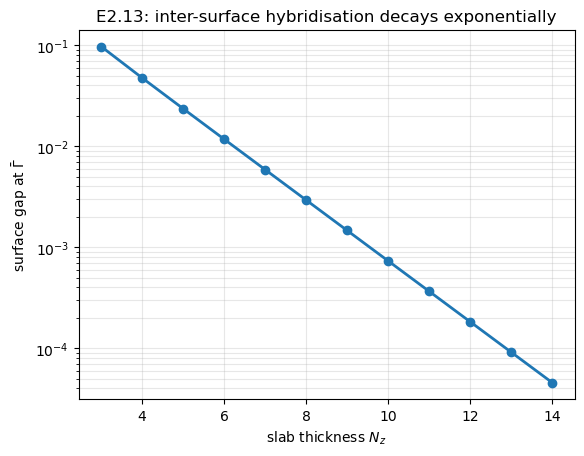

penetration depth from the fit: xi = 1.44 layers


In [14]:
# NB: m0 = 2.0 is a special point of this model where the surface state is
# EXACTLY one-layer localized (the analogue of the Kitaev t = Delta sweet
# spot): the hybridisation gap is machine zero at every thickness.  Move
# slightly off it to see the generic exponential decay.
m0_thin = 2.5
gaps, Nzs = [], range(3, 15)
for Nz in Nzs:
    hopz = -0.5 * G0 + lam3 * Gz / 2j
    on = (m0_thin - 2.0) * G0    # kx = ky = 0
    H = np.zeros((4 * Nz, 4 * Nz), complex)
    for z in range(Nz):
        H[4*z:4*z+4, 4*z:4*z+4] = on
        if z + 1 < Nz:
            H[4*z:4*z+4, 4*z+4:4*z+8] = hopz
            H[4*z+4:4*z+8, 4*z:4*z+4] = hopz.conj().T
    gaps.append(np.abs(np.linalg.eigvalsh(H)).min())
pyplot.semilogy(list(Nzs), gaps, 'o-', lw=2)
pyplot.xlabel("slab thickness $N_z$"); pyplot.ylabel("surface gap at $\\bar\\Gamma$")
pyplot.title("E2.13: inter-surface hybridisation decays exponentially")
pyplot.grid(alpha=.3, which='both'); pyplot.show()
xi = -1 / np.polyfit(list(Nzs)[4:], np.log(gaps[4:]), 1)[0]
print(f"penetration depth from the fit: xi = {xi:.2f} layers")
assert gaps[-1] < gaps[0] * 1e-2

## E2.14 ◦ (pencil) — Particle-hole symmetry pins E = 0
*(original)*

PH symmetry gives an antiunitary $P$ with $PHP^{-1} = -H$ and $P^2=+1$
(class D).  If $H\psi = E\psi$ then $H(P\psi) = -E(P\psi)$: the spectrum is
symmetric about zero.  Levels can only leave $E=0$ in $\pm E$ *pairs*.  A
single level at $E=0$ (one Majorana per end, with its partner far away) has
no partner to pair with: no PH-symmetric perturbation can move it.  Only
closing the bulk gap — merging it with the continuum — or coupling the two
ends (finite-size overlap) can shift it.  That is the entire protection
argument, and why the ZBP of §18-19 is pinned at $2e^2/h$.

---
*End of the Part II solutions.  Solutions marked "original" were written
for this course; all others follow the flagged source.  If a solution
disagrees with your own, trust neither blindly: re-derive.*
